# Introduction to Deep Learning — Session 3: Natural Language Processing

**Prerequisites:** Sessions 1 and 2. You need neurons, backpropagation, embeddings-as-parameters thinking, and the idea of an **inductive bias** — choosing an architecture that matches the structure of the data.

**The pattern we have followed twice already:**

| Session | The naive representation | Why it fails | The fix |
|---|---|---|---|
| 1 | raw features + hand-made polynomials | doesn't scale, needs human insight | let the network learn features |
| 2 | flattened pixels | destroys 2D geometry | convolution: locality + weight sharing |
| **3** | **one-hot words** | **destroys meaning and order** | **embeddings + sequence models** |

Today is short but foundational: how a word becomes a vector, why Word2Vec was a breakthrough, and which architectures fit sequences.

| Part | Topic |
|---|---|
| 1 | From text to numbers: tokens, vocabulary, one-hot |
| 2 | Embeddings and Word2Vec |
| 3 | Networks for sequences: bag-of-words, RNN/LSTM, attention |
| 4 | Summary, exercises, resources |

---

## 0. Setup

We need `numpy`, `matplotlib` and `torch`. No dataset downloads — we generate a small corpus with a **known** semantic structure, which makes it possible to actually *verify* that the model learned what we claim.

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

np.random.seed(0)
torch.manual_seed(0)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"] = 9

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("torch:", torch.__version__, "| device:", device)

torch: 2.13.0 | device: cpu


---

# Part 1 — From text to numbers

A neural network multiplies matrices. It cannot multiply the word *"cat"*. So the very first question in NLP is: **what number, or vector of numbers, represents a word?**

## 1.1 Tokenization and the vocabulary

Before anything else, text has to be cut into pieces called **tokens**. The simplest rule is "split on spaces", which is what we will use. Real systems are more careful, because the choice has consequences:

| Level | `"unbelievable"` becomes | Trade-off |
|---|---|---|
| character | `u n b e l i e v a b l e` | tiny vocabulary, but very long sequences and no word meaning |
| **word** | `unbelievable` | intuitive, but a huge vocabulary and unknown words break it |
| **subword (BPE)** | `un ##believ ##able` | the modern default: fixed vocabulary, no unknown words, keeps morphology |

Every large language model today uses subword tokenization. We use word-level here because it makes the ideas easiest to see.

Once tokenized, we collect every distinct token into a **vocabulary** and give each one an integer id.

In [6]:
corpus_demo = [
    "the cat drinks the milk",
    "the dog eats the meat",
    "the king rules the kingdom",
]

def tokenize(text):
    return text.lower().split()

tokens = [t for s in corpus_demo for t in tokenize(s)]
vocab = sorted(set(tokens))
word2id = {w: i for i, w in enumerate(vocab)}
id2word = {i: w for w, i in word2id.items()}

print("tokens        :", tokens[:10], "...")
print("vocabulary    :", vocab)
print("vocabulary size:", len(vocab))
print("\nword -> id:", {w: word2id[w] for w in ["cat", "dog", "milk", "the"]})
print("\n'the cat drinks the milk' ->",
      [word2id[t] for t in tokenize("the cat drinks the milk")])

tokens        : ['the', 'cat', 'drinks', 'the', 'milk', 'the', 'dog', 'eats', 'the', 'meat'] ...
vocabulary    : ['cat', 'dog', 'drinks', 'eats', 'king', 'kingdom', 'meat', 'milk', 'rules', 'the']
vocabulary size: 10

word -> id: {'cat': 0, 'dog': 1, 'milk': 7, 'the': 9}

'the cat drinks the milk' -> [9, 0, 2, 9, 7]


## 1.2 Why not just use the id?

Tempting: `cat = 3`, `dog = 4`, `king = 6`. One number per word, done.

This is badly wrong, and the reason is worth stating precisely: **integers carry an order and a distance that the words do not have.** The model would conclude that `king (6)` is twice `cat (3)`, and that `cat` is closer to `dog` than to `king` — purely because of alphabetical accident. We would be feeding the network a completely fictional structure.

(The same objection applies to any categorical variable — country, colour, product id. It is not an NLP-specific problem.)

## 1.3 One-hot vectors

The standard fix is the **one-hot vector**: a vector as long as the vocabulary, with a single 1 at the word's position and 0 everywhere else.

$$\text{cat} = [0, 0, 1, 0, \dots, 0] \in \mathbb{R}^{|V|}$$

Now no word is "greater" than another, and every word is treated symmetrically. That solves the false-ordering problem.

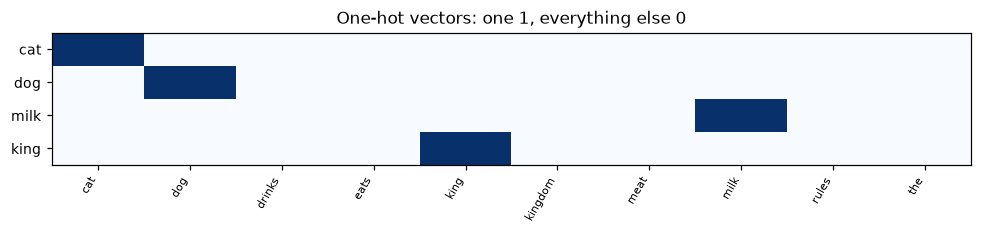

vector for 'cat': [1 0 0 0 0 0 0 0 0 0]


In [7]:
def one_hot(word, word2id):
    v = np.zeros(len(word2id))
    v[word2id[word]] = 1.0
    return v

show = ["cat", "dog", "milk", "king"]
M = np.stack([one_hot(w, word2id) for w in show])

fig, ax = plt.subplots(figsize=(9, 2.2))
ax.imshow(M, cmap="Blues", aspect="auto")
ax.set_xticks(range(len(vocab)), vocab, rotation=60, ha="right", fontsize=7)
ax.set_yticks(range(len(show)), show, fontsize=9)
ax.set_title("One-hot vectors: one 1, everything else 0")
plt.tight_layout(); plt.show()

print("vector for 'cat':", one_hot("cat", word2id).astype(int))

### The two problems with one-hot

**Problem 1 — the vectors are enormous and empty.**
Our toy vocabulary has a dozen words. A realistic English vocabulary has 50,000–500,000. So every word is a 100,000-dimensional vector in which **one** entry is non-zero. A dense layer taking that input has 100,000 weights per neuron, and 99.999% of the multiplications are by zero.

**Problem 2 — and this is the fatal one — every word is equally far from every other word.**

The dot product of two different one-hot vectors is always exactly 0, so their cosine similarity is 0. Always. For every pair.

In [8]:
def cosine(a, b):
    return float(a @ b / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-12))

pairs = [("cat", "dog"), ("cat", "milk"), ("cat", "king"), ("milk", "meat")]
print("cosine similarity between one-hot vectors")
print("-" * 42)
for a, b in pairs:
    print(f"  {a:>5} vs {b:<8}: {cosine(one_hot(a, word2id), one_hot(b, word2id)):.1f}")

print("\nEvery pair: 0.0. To this representation, 'cat' and 'dog' are exactly")
print("as unrelated as 'cat' and 'kingdom'. All the meaning is gone.")

cosine similarity between one-hot vectors
------------------------------------------
    cat vs dog     : 0.0
    cat vs milk    : 0.0
    cat vs king    : 0.0
   milk vs meat    : 0.0

Every pair: 0.0. To this representation, 'cat' and 'dog' are exactly
as unrelated as 'cat' and 'kingdom'. All the meaning is gone.


This is the same kind of loss we saw in Session 2. Flattening threw away the fact that neighbouring **pixels** are related; one-hot throws away the fact that some **words** are related.

The consequence is concrete: a model trained on sentences containing *"the cat drinks milk"* learns nothing at all that helps it with *"the kitten drinks milk"*. Every word must be learned from scratch, independently. With a 100,000-word vocabulary and a long tail of rare words, most words will be seen only a handful of times — so most of the vocabulary is never learned properly.

## 1.4 A note on bag-of-words

Before neural NLP, the standard way to represent a whole *document* was to add up its one-hot vectors: a count of how often each word appears. That is the **bag-of-words** model (often weighted by TF-IDF).

It works surprisingly well for topic classification and spam filtering, and it is still a good baseline. But the name says the flaw out loud — it is a *bag*, so word **order is thrown away**:

> `"the dog chased the cat"` and `"the cat chased the dog"` have **identical** bag-of-words vectors.

Two different problems, then, and we need two different fixes:

| Problem | Fix | Part |
|---|---|---|
| words have no notion of similarity | **embeddings** (Word2Vec) | 2 |
| order and context are ignored | **sequence models** (RNN, attention) | 3 |

---

# Part 2 — Embeddings and Word2Vec

## 2.1 The idea: give each word a short, dense, *learned* vector

Instead of a 100,000-dimensional vector with one 1 in it, give each word a vector of, say, 100 real numbers — and **make those numbers parameters of the model**, learned by gradient descent like any weight.

$$\text{cat} \;\rightarrow\; [\,0.21,\; -0.94,\; 0.33,\; \dots,\; 0.07\,] \in \mathbb{R}^{100}$$

This is an **embedding**. Three things change immediately:

* **Size**: 100 numbers instead of 100,000.
* **Similarity**: two words can now be close, far, or anywhere in between. Similar words can end up near each other.
* **Sharing**: what the model learns about *"cat"* automatically helps with *"kitten"*, if their vectors are close.

Nobody assigns these numbers by hand. They are learned — exactly the Session 1 lesson again, applied one level deeper: we stopped hand-designing features, then hand-designing feature extractors, and now we stop hand-designing the input representation itself.

### An embedding layer is just a lookup — and also just a matrix multiply

`nn.Embedding(V, d)` holds a $V \times d$ matrix; row $i$ is the vector of word $i$. Looking up a word is the same thing as multiplying its one-hot vector by that matrix — just without doing 99,999 pointless multiplications by zero.

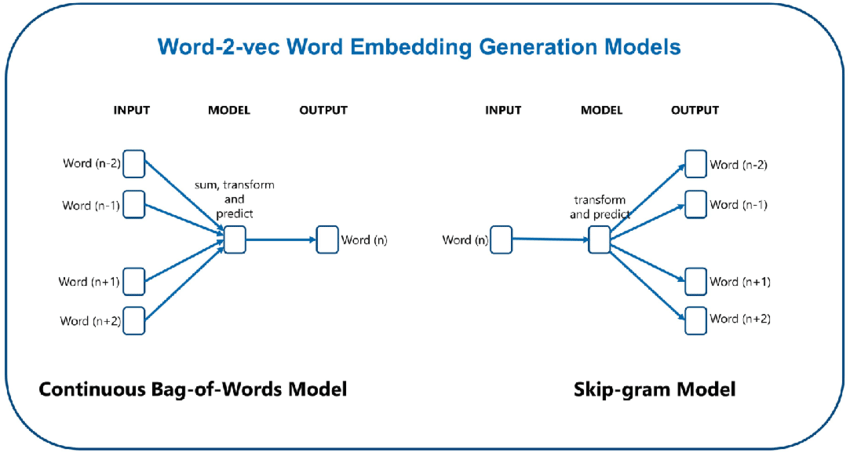

In [9]:
V, d = 12, 4
emb = nn.Embedding(V, d)
print("embedding matrix shape:", tuple(emb.weight.shape), " (vocab_size, dim)")

idx = torch.tensor([3])
onehot = F.one_hot(idx, V).float()

print("\nlookup   emb(3)      :", emb(idx).detach().numpy().round(3))
print("matmul   onehot @ W  :", (onehot @ emb.weight).detach().numpy().round(3))
print("\nIdentical. 'Lookup' is the efficient implementation of 'multiply by one-hot'.")
print("So an embedding layer is an ordinary linear layer - it just has a fast path.")

embedding matrix shape: (12, 4)  (vocab_size, dim)

lookup   emb(3)      : [[ 0.12   1.238  1.117 -0.247]]
matmul   onehot @ W  : [[ 0.12   1.238  1.117 -0.247]]

Identical. 'Lookup' is the efficient implementation of 'multiply by one-hot'.
So an embedding layer is an ordinary linear layer - it just has a fast path.


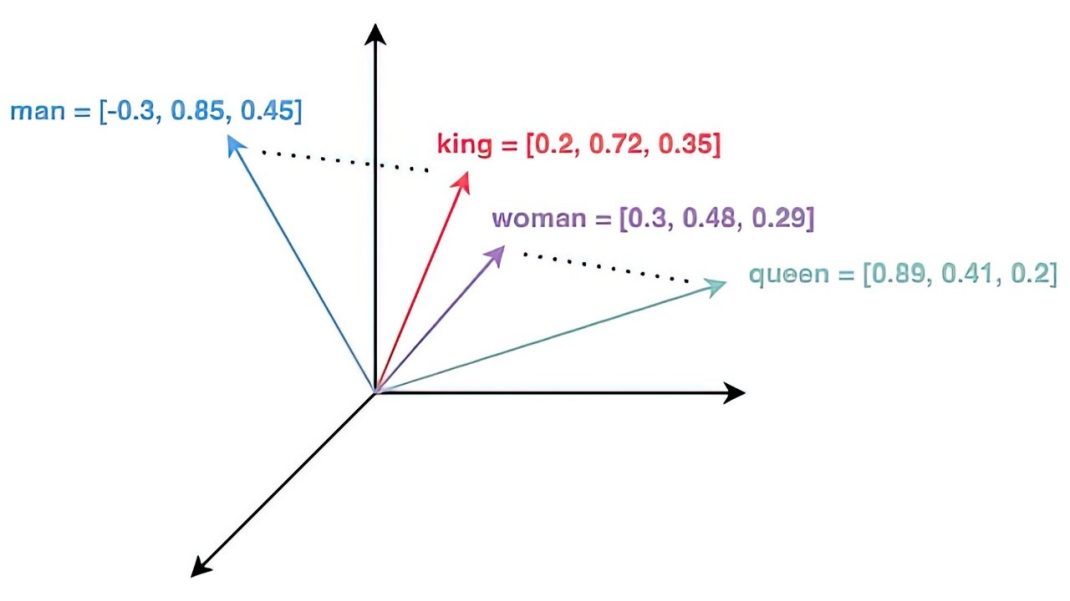

## 2.2 Where do the numbers come from? The distributional hypothesis

If the vectors are learned, they must be learned from *some* training signal. Word2Vec's answer rests on an old idea from linguistics:

> **"You shall know a word by the company it keeps."** — J.R. Firth, 1957

Words that appear in similar contexts tend to mean similar things. You have never seen the word *"wug"*, but from

* *"she poured the wug into her cup"*
* *"the wug was too hot to drink"*
* *"he ordered a wug with milk"*

you already know roughly what it means. You inferred meaning purely from context — and context is something we have in unlimited quantity, for free, in any pile of raw text. **No labels needed.**

That is Word2Vec (Mikolov et al., 2013): turn "predict the context" into a supervised task, train a network on it, and then **throw the network away and keep the embedding matrix**. The embeddings were never the goal of the task; they are a by-product.

### Two variants

| Variant | Task |
|---|---|
| **CBOW** | given the surrounding words, predict the middle word |
| **Skip-gram** | given the middle word, predict each surrounding word |

Skip-gram works better on small corpora and rare words, so we implement that one.

### The training pairs

Slide a window (say ±2 words) over the text. Every (centre, context) pair inside a window is a positive example.

```
"the   cat   drinks   the   milk"
        ^centre
pairs:  (cat, the)  (cat, drinks)  (cat, the)
```

In [10]:
# ---- a small corpus with a KNOWN semantic structure, so we can check the result
CATEGORIES = {
    "ANIMAL": ["cat", "dog", "mouse", "horse", "bird", "fish"],
    "FOOD":   ["milk", "meat", "bread", "cheese", "grain", "seed"],
    "PERSON": ["king", "queen", "farmer", "baker", "soldier", "child"],
    "PLACE":  ["barn", "castle", "market", "river", "forest", "kitchen"],
}

TEMPLATES = [
    "a ANIMAL eats FOOD",
    "a ANIMAL sleeps in a PLACE",
    "a ANIMAL runs through a PLACE",
    "a ANIMAL hides in a PLACE",
    "a hungry ANIMAL wants FOOD",
    "a small ANIMAL fears a PERSON",
    "a PERSON feeds FOOD to a ANIMAL",
    "a PERSON buys FOOD in a PLACE",
    "a PERSON cooks FOOD",
    "a PERSON sells FOOD",
    "a PERSON walks to a PLACE",
    "a PERSON visits a PLACE",
    "a rich PERSON owns a PLACE",
    "FOOD comes from a PLACE",
    "fresh FOOD tastes good",
]


def make_corpus(n=12000, seed=0):
    rng = np.random.default_rng(seed)
    out = []
    for _ in range(n):
        s = TEMPLATES[rng.integers(len(TEMPLATES))]
        for cat, words in CATEGORIES.items():
            while cat in s:
                s = s.replace(cat, words[rng.integers(len(words))], 1)
        out.append(s)
    return out


corpus = make_corpus()
print("example sentences:")
for s in corpus[:6]:
    print("  ", s)

tok_corpus = [tokenize(s) for s in corpus]
all_tokens = [t for s in tok_corpus for t in s]
vocab = sorted(set(all_tokens))
word2id = {w: i for i, w in enumerate(vocab)}
id2word = {i: w for w, i in word2id.items()}
V = len(vocab)

print(f"\nsentences: {len(corpus)}   tokens: {len(all_tokens):,}   vocabulary: {V}")
print("vocabulary:", vocab)

example sentences:
   a rich baker owns a river
   a hungry dog wants milk
   a cat sleeps in a castle
   a rich baker owns a kitchen
   a child buys cheese in a forest
   a baker sells cheese

sentences: 12000   tokens: 64,716   vocabulary: 49
vocabulary: ['a', 'baker', 'barn', 'bird', 'bread', 'buys', 'castle', 'cat', 'cheese', 'child', 'comes', 'cooks', 'dog', 'eats', 'farmer', 'fears', 'feeds', 'fish', 'forest', 'fresh', 'from', 'good', 'grain', 'hides', 'horse', 'hungry', 'in', 'king', 'kitchen', 'market', 'meat', 'milk', 'mouse', 'owns', 'queen', 'rich', 'river', 'runs', 'seed', 'sells', 'sleeps', 'small', 'soldier', 'tastes', 'through', 'to', 'visits', 'walks', 'wants']


In [11]:
def make_skipgram_pairs(tok_corpus, word2id, window=2):
    """Every (centre, context) pair inside a +/- window."""
    centres, contexts = [], []
    for sent in tok_corpus:
        ids = [word2id[t] for t in sent]
        for i, c in enumerate(ids):
            lo, hi = max(0, i - window), min(len(ids), i + window + 1)
            for j in range(lo, hi):
                if j != i:
                    centres.append(c)
                    contexts.append(ids[j])
    return np.array(centres), np.array(contexts)


centres, contexts = make_skipgram_pairs(tok_corpus, word2id)
print(f"training pairs: {len(centres):,}")
print("\nfirst sentence:", " ".join(tok_corpus[0]))
print("its first few pairs:")
for c, o in list(zip(centres[:6], contexts[:6])):
    print(f"   centre='{id2word[c]}'  ->  context='{id2word[o]}'")

training pairs: 186,864

first sentence: a rich baker owns a river
its first few pairs:
   centre='a'  ->  context='rich'
   centre='a'  ->  context='baker'
   centre='rich'  ->  context='a'
   centre='rich'  ->  context='baker'
   centre='rich'  ->  context='owns'
   centre='baker'  ->  context='a'


## 2.3 Negative sampling

The obvious model is: embed the centre word, multiply by an output matrix of size $d \times |V|$, softmax over the whole vocabulary. That works, but the softmax denominator sums over **every word in the vocabulary** for every single training pair. With a 100,000-word vocabulary and billions of pairs, it is far too slow.

**Negative sampling** replaces one $|V|$-way classification with a handful of binary ones:

> For each real (centre, context) pair, also draw $k$ random words that are *not* the context. Then train a binary classifier: "is this a real pair, or a fake one?"

$$\mathcal{L} = -\log \sigma(v_c \cdot u_o) \;-\; \sum_{i=1}^{k} \log \sigma(-\,v_c \cdot u_{n_i})$$

Read it as: **push the centre vector towards words it really occurs with, and away from random words.** The similarity measure is a dot product, so "pushing together" literally means making the vectors point in the same direction — which is why cosine similarity is meaningful afterwards.

Cost per pair drops from $|V|$ to $k+1$ (typically $k = 5$).

Negative words are drawn from the unigram frequency raised to the power $0.75$ — a heuristic that samples frequent words often enough to be useful, but not so often that *"the"* dominates.

In [12]:
class SkipGramNS(nn.Module):
    """Skip-gram with negative sampling. Two embedding tables: one for the word
    as a centre, one for the word as a context."""

    def __init__(self, vocab_size, dim=32):
        super().__init__()
        self.centre = nn.Embedding(vocab_size, dim)
        self.context = nn.Embedding(vocab_size, dim)
        nn.init.normal_(self.centre.weight, std=0.1)
        nn.init.zeros_(self.context.weight)

    def forward(self, c_ids, o_ids, neg_ids):
        v = self.centre(c_ids)                      # (B, d)
        u_pos = self.context(o_ids)                 # (B, d)
        u_neg = self.context(neg_ids)               # (B, k, d)

        pos_score = (v * u_pos).sum(1)                          # (B,)
        neg_score = torch.bmm(u_neg, v.unsqueeze(2)).squeeze(2)  # (B, k)

        pos_loss = F.logsigmoid(pos_score)
        neg_loss = F.logsigmoid(-neg_score).sum(1)
        return -(pos_loss + neg_loss).mean()


# unigram^0.75 sampling distribution for the negatives
counts = np.bincount([word2id[t] for t in all_tokens], minlength=V).astype(float)
neg_dist = counts ** 0.75
neg_dist /= neg_dist.sum()

print("most frequent words:", [id2word[i] for i in np.argsort(-counts)[:5]])
print("their raw share    :", np.round((counts / counts.sum())[np.argsort(-counts)[:5]], 3))
print("after the ^0.75 fix:", np.round(neg_dist[np.argsort(-counts)[:5]], 3))

most frequent words: ['a', 'in', 'to', 'cheese', 'bread']
their raw share    : [0.284 0.037 0.025 0.018 0.017]
after the ^0.75 fix: [0.16  0.035 0.026 0.02  0.019]


In [13]:
import time

def train_word2vec(centres, contexts, dim=48, k=5, epochs=5, batch=4096, lr=5e-3):
    model = SkipGramNS(V, dim).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    n = len(centres)
    c_all = torch.from_numpy(centres).long()
    o_all = torch.from_numpy(contexts).long()
    rng = np.random.default_rng(0)

    t0 = time.time()
    for ep in range(epochs):
        perm = torch.from_numpy(rng.permutation(n))
        total = 0.0
        for s in range(0, n, batch):
            idx = perm[s:s + batch]
            c, o = c_all[idx].to(device), o_all[idx].to(device)
            neg = torch.from_numpy(
                rng.choice(V, size=(len(idx), k), p=neg_dist)).long().to(device)
            loss = model(c, o, neg)
            opt.zero_grad(); loss.backward(); opt.step()
            total += loss.item() * len(idx)
        print(f"epoch {ep+1}/{epochs}  loss {total/n:.4f}")
    print(f"took {time.time()-t0:.1f}s")
    return model


w2v = train_word2vec(centres, contexts)
E = w2v.centre.weight.detach().cpu().numpy()       # (V, dim) - the embeddings we wanted
print("\nembedding matrix:", E.shape)

epoch 1/5  loss 3.2812
epoch 2/5  loss 2.6169
epoch 3/5  loss 2.4256
epoch 4/5  loss 2.1766
epoch 5/5  loss 2.0386
took 0.4s

embedding matrix: (49, 48)


## 2.4 Did it work?

The whole point of using a corpus with known structure is that we can check. We never told the model that *cat* and *dog* belong together — it only ever saw them as ids in sentences. If the nearest neighbours of *cat* are other animals, the model discovered the category from context alone.

In [14]:
En = E / (np.linalg.norm(E, axis=1, keepdims=True) + 1e-9)     # normalize -> dot = cosine

def nearest(word, k=5):
    q = En[word2id[word]]
    sims = En @ q
    order = np.argsort(-sims)
    return [(id2word[i], float(sims[i])) for i in order if i != word2id[word]][:k]

word_cat = {w: c for c, ws in CATEGORIES.items() for w in ws}

for w in ["cat", "milk", "king", "castle"]:
    nbrs = nearest(w)
    same = sum(word_cat.get(n, "?") == word_cat.get(w) for n, _ in nbrs)
    print(f"{w:>8} ({word_cat[w]:>6}) -> " +
          ", ".join(f"{n}({s:.2f})" for n, s in nbrs) +
          f"    [{same}/5 from the same category]")

print("\nThe model was never told these categories. It inferred them from context.")

     cat (ANIMAL) -> horse(0.96), bird(0.96), fish(0.95), dog(0.95), mouse(0.93)    [5/5 from the same category]
    milk (  FOOD) -> seed(0.95), meat(0.95), grain(0.94), bread(0.94), cheese(0.93)    [5/5 from the same category]
    king (PERSON) -> queen(0.96), baker(0.94), soldier(0.94), farmer(0.93), child(0.93)    [5/5 from the same category]
  castle ( PLACE) -> market(0.97), forest(0.96), barn(0.96), river(0.96), kitchen(0.96)    [5/5 from the same category]

The model was never told these categories. It inferred them from context.


In [15]:
# compare with what one-hot gave us
print("cosine similarity:      one-hot   |   learned embedding")
print("-" * 55)
for a, b in [("cat", "dog"), ("milk", "bread"), ("king", "queen"),
             ("cat", "milk"), ("cat", "king")]:
    oh = 0.0
    em = float(En[word2id[a]] @ En[word2id[b]])
    print(f"  {a:>6} vs {b:<8}: {oh:>8.2f}   |   {em:>8.2f}")

cosine similarity:      one-hot   |   learned embedding
-------------------------------------------------------
     cat vs dog     :     0.00   |       0.95
    milk vs bread   :     0.00   |       0.94
    king vs queen   :     0.00   |       0.96
     cat vs milk    :     0.00   |       0.21
     cat vs king    :     0.00   |       0.40


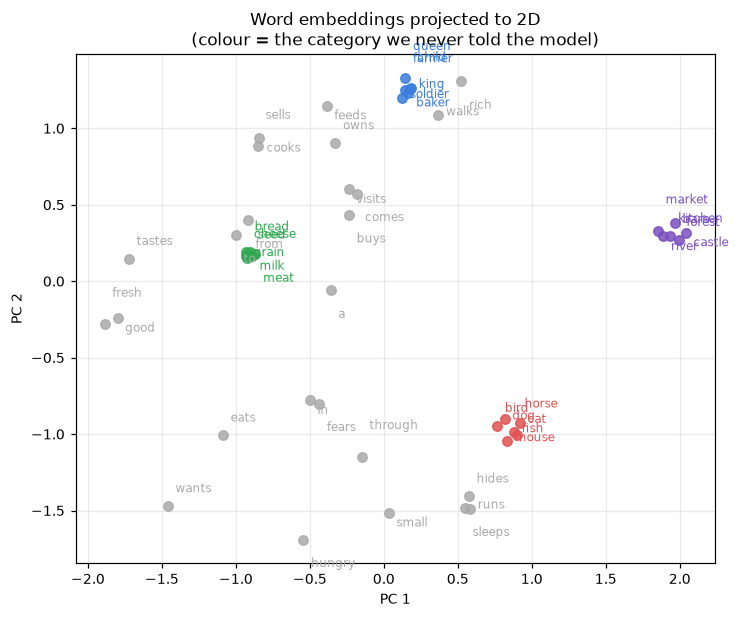

Grey words (a, in, to, from, and the adjectives) form their own region:
their contexts are unlike any content word's, so they end up elsewhere.


In [16]:
# project the embeddings to 2D with PCA (plain numpy SVD) and look at the map
Ec = E - E.mean(axis=0)
U, S, Vt = np.linalg.svd(Ec, full_matrices=False)
P = Ec @ Vt[:2].T

colors = {"ANIMAL": "#e05252", "FOOD": "#2fa84f", "PERSON": "#3a7ddc",
          "PLACE": "#7a4fbf", None: "#aaaaaa"}

plt.figure(figsize=(7.5, 6))
for i, w in enumerate(vocab):
    c = colors[word_cat.get(w)]
    plt.scatter(P[i, 0], P[i, 1], color=c, s=38, zorder=3, alpha=0.85)
    # stagger the labels vertically, otherwise the tight clusters overlap
    plt.annotate(w, (P[i, 0], P[i, 1]), fontsize=8,
                 xytext=(5, 9 * ((i % 5) - 2)), textcoords="offset points", color=c)
plt.title("Word embeddings projected to 2D\n(colour = the category we never told the model)")
plt.xlabel("PC 1"); plt.ylabel("PC 2"); plt.grid(alpha=0.25)
plt.show()

print("Grey words (a, in, to, from, and the adjectives) form their own region:")
print("their contexts are unlike any content word's, so they end up elsewhere.")

## 2.5 What this buys you, and what it does not

**The famous property.** On a large real corpus, embeddings encode relationships as *directions*, so vector arithmetic works:

$$\text{king} - \text{man} + \text{woman} \approx \text{queen}, \qquad
\text{Paris} - \text{France} + \text{Italy} \approx \text{Rome}$$

The direction "male → female" and the direction "country → capital" are consistent across the whole space. Our toy corpus is far too small and too regular to show this, but it is the result that made Word2Vec famous in 2013.

**The family of methods.**

| Method | Idea |
|---|---|
| **Word2Vec** (2013) | predict context words (what we just built) |
| **GloVe** (2014) | factorize the global word co-occurrence matrix instead |
| **fastText** (2016) | embed character n-grams too, so unseen and misspelled words still get a vector |

**The limitation that ended this era.** Every method above gives each word **exactly one vector**, no matter how it is used:

* *"I sat on the river **bank**"*
* *"I withdrew money from the **bank**"*

Same vector. It ends up as a useless average of both senses. And a single fixed vector cannot represent *"not good"* differently from *"good"*, because it does not see the sentence at all.

The fix is **contextual embeddings**: compute a word's vector *as a function of the sentence it appears in*. That requires a model that reads sequences — which is exactly Part 3, and it leads directly to ELMo, BERT and every modern language model.

> Static embeddings are far from obsolete, though. They are small, fast, interpretable, and completely sufficient for search, recommendation, clustering and many classification tasks. Start with them.

---

# Part 3 — Networks for sequences

Embeddings fixed the *word* representation. Now we need a network that can consume a **sentence**. Text brings two structural problems that images do not:

**1. Variable length.** A dense layer needs a fixed-size input. Sentences have 3 words or 300.

**2. Order carries meaning.** *"the dog chased the cat"* and *"the cat chased the dog"* use identical words and mean opposite things.

Just like in Session 2, the question is which **inductive bias** matches this structure.

## 3.1 Padding and masking

The standard engineering answer to variable length: pad every sentence in a batch to the same length with a special `<pad>` token, and carry a **mask** saying which positions are real. Forgetting the mask is one of the most common bugs in NLP code — the model happily learns from padding.

In [17]:
PAD = "<pad>"

def encode(sentences, w2i, max_len):
    """Turn a list of token lists into a padded (N, max_len) id array plus a mask."""
    X = np.full((len(sentences), max_len), w2i[PAD], dtype=np.int64)
    mask = np.zeros((len(sentences), max_len), dtype=np.float32)
    for i, toks in enumerate(sentences):
        ids = [w2i[t] for t in toks][:max_len]
        X[i, :len(ids)] = ids
        mask[i, :len(ids)] = 1.0
    return X, mask


demo_sents = [tokenize(s) for s in ["a cat eats milk", "a rich king owns a castle"]]
demo_vocab = {PAD: 0, **{w: i + 1 for i, w in enumerate(sorted({t for s in demo_sents for t in s}))}}
Xd, Md = encode(demo_sents, demo_vocab, max_len=7)
print("ids:\n", Xd)
print("\nmask (1 = real token, 0 = padding):\n", Md.astype(int))

ids:
 [[1 3 4 6 0 0 0]
 [1 8 5 7 1 2 0]]

mask (1 = real token, 0 = padding):
 [[1 1 1 1 0 0 0]
 [1 1 1 1 1 1 0]]


## 3.2 Baseline: average the embeddings

The simplest sentence model: embed every word, then **average** the vectors. Any length in, one fixed vector out.

$$\text{sentence vector} = \frac{1}{L}\sum_{i=1}^{L} \mathbf{e}_{w_i}$$

This is "bag of words, but with embeddings" — sometimes called a *deep averaging network*. It is a genuinely strong baseline for topic classification and sentiment, it trains in seconds, and you should always try it before anything fancier.

But look at the formula: addition is commutative. **Shuffle the words and the output is identical.** Order is gone, exactly as in classic bag-of-words.

Let's find a task where that is fatal.

## 3.3 A task where order is everything

Sentences of the form `"the X chased the Y"`, where X and Y are animals. The label is **who did the chasing** — the subject.

For every pair of animals, both orderings appear equally often in the data. So a model that only sees *which* words are present, not *where*, cannot do better than guessing between the two — a ceiling of about 50%.

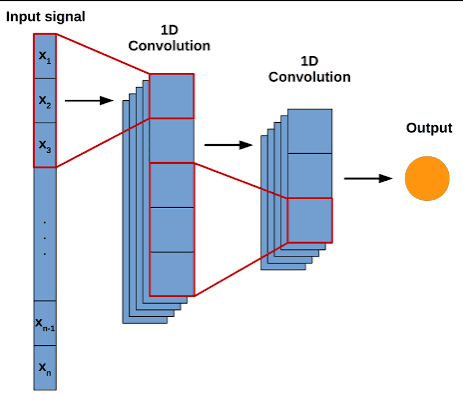

<div align="center">

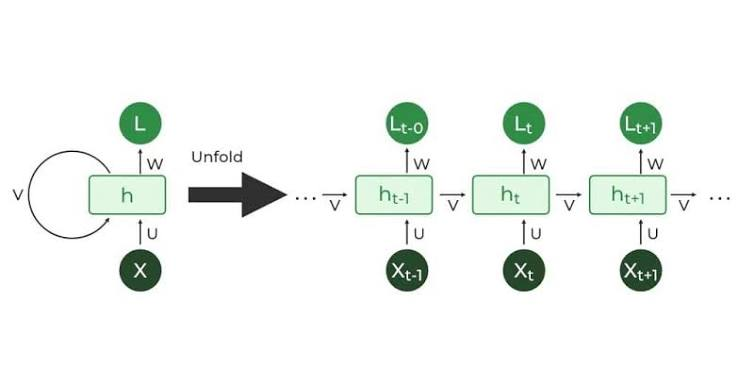

In [18]:
ANIMALS = ["cat", "dog", "mouse", "horse", "bird", "fish"]
CHASE_VERBS = ["chased", "caught", "followed", "watched"]

def make_chase_data(n=8000, seed=0):
    rng = np.random.default_rng(seed)
    sents, labels = [], []
    for _ in range(n):
        i, j = rng.choice(len(ANIMALS), size=2, replace=False)
        v = CHASE_VERBS[rng.integers(len(CHASE_VERBS))]
        sents.append(f"the {ANIMALS[i]} {v} the {ANIMALS[j]}".split())
        labels.append(i)                       # the label is the SUBJECT
    return sents, np.array(labels)


chase_sents, chase_y = make_chase_data()
chase_words = sorted({t for s in chase_sents for t in s})
cw2i = {PAD: 0, **{w: i + 1 for i, w in enumerate(chase_words)}}
MAXLEN = 5

Xc, Mc = encode(chase_sents, cw2i, MAXLEN)

print("examples:")
for k in range(4):
    print(f"   {' '.join(chase_sents[k]):<32} -> subject = {ANIMALS[chase_y[k]]}")

# proof that the bag of words is identical for the two orders
from collections import Counter
a = Counter("the cat chased the dog".split())
b = Counter("the dog chased the cat".split())
print(f"\nword counts of 'the cat chased the dog': {dict(a)}")
print(f"word counts of 'the dog chased the cat': {dict(b)}")
print(f"identical? {a == b}")

# train / validation split
n_tr = 6000
Xtr, Mtr, ytr = Xc[:n_tr], Mc[:n_tr], chase_y[:n_tr]
Xva, Mva, yva = Xc[n_tr:], Mc[n_tr:], chase_y[n_tr:]
print(f"\ntrain {len(ytr)}  validation {len(yva)}  vocabulary {len(cw2i)}  classes {len(ANIMALS)}")

examples:
   the bird caught the horse        -> subject = bird
   the cat chased the dog           -> subject = cat
   the cat watched the bird         -> subject = cat
   the mouse followed the horse     -> subject = mouse

word counts of 'the cat chased the dog': {'the': 2, 'cat': 1, 'chased': 1, 'dog': 1}
word counts of 'the dog chased the cat': {'the': 2, 'dog': 1, 'chased': 1, 'cat': 1}
identical? True

train 6000  validation 2000  vocabulary 12  classes 6


In [19]:
class MeanEmbedding(nn.Module):
    """Embed, average over the real tokens, classify. No notion of order."""

    def __init__(self, vocab, dim, n_classes):
        super().__init__()
        self.emb = nn.Embedding(vocab, dim, padding_idx=0)
        self.fc = nn.Linear(dim, n_classes)

    def forward(self, x, mask):
        e = self.emb(x) * mask.unsqueeze(-1)               # zero out the padding
        pooled = e.sum(1) / mask.sum(1, keepdim=True)      # masked mean
        return self.fc(pooled)


def train_seq(model, Xtr, Mtr, ytr, Xva, Mva, yva, epochs=8, lr=3e-3, batch=128, verbose=False):
    model = model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    crit = nn.CrossEntropyLoss()
    Xt, Mt, yt = (torch.from_numpy(a).to(device) for a in (Xtr, Mtr, ytr))
    Xv, Mv, yv = (torch.from_numpy(a).to(device) for a in (Xva, Mva, yva))
    hist = []
    for ep in range(epochs):
        model.train()
        perm = torch.randperm(len(yt), device=device)
        for s in range(0, len(yt), batch):
            i = perm[s:s + batch]
            opt.zero_grad()
            loss = crit(model(Xt[i], Mt[i]), yt[i])
            loss.backward(); opt.step()
        model.eval()
        with torch.no_grad():
            acc = (model(Xv, Mv).argmax(1) == yv).float().mean().item()
        hist.append(acc)
        if verbose:
            print(f"  epoch {ep+1}/{epochs}  val acc {acc*100:5.1f}%")
    return hist


print("=== Model 1: mean of embeddings ===")
h_mean = train_seq(MeanEmbedding(len(cw2i), 32, len(ANIMALS)),
                   Xtr, Mtr, ytr, Xva, Mva, yva, verbose=True)
print(f"\nbest validation accuracy: {max(h_mean)*100:.1f}%")
print("Around 50%, exactly as predicted: it knows WHICH two animals, never WHICH ONE was first.")

=== Model 1: mean of embeddings ===
  epoch 1/8  val acc  49.1%
  epoch 2/8  val acc  48.4%
  epoch 3/8  val acc  48.6%
  epoch 4/8  val acc  48.3%
  epoch 5/8  val acc  48.9%
  epoch 6/8  val acc  47.7%
  epoch 7/8  val acc  49.2%
  epoch 8/8  val acc  48.6%

best validation accuracy: 49.2%
Around 50%, exactly as predicted: it knows WHICH two animals, never WHICH ONE was first.


## 3.4 Recurrent networks

The first architecture built for sequences: read the sentence **one word at a time**, keeping a running summary called the **hidden state**.

$$h_t = \tanh\big(W_x \mathbf{e}_{w_t} + W_h h_{t-1} + b\big)$$

Note what this is: the same weights $W_x, W_h$ applied at every time step — **weight sharing along time**, the direct analogue of convolution's weight sharing across space. And because $h_t$ depends on $h_{t-1}$, the order of the inputs changes the result. Order is built into the architecture.

Any length works: just keep stepping. The final $h_T$ is a fixed-size summary of the whole sentence.

### Why LSTM and not a plain RNN

A plain RNN multiplies by $W_h$ at every step. Over 50 words that is $W_h^{50}$ — and Session 1, Part 6.4 already told us what repeated multiplication does to gradients: they vanish (or explode). In practice a simple RNN cannot connect information more than a handful of words apart.

The **LSTM** (1997) adds a separate *cell state* that flows through the sequence with only additive updates, plus three learned **gates** that decide what to forget, what to write, and what to read out. The additive path is the same trick as ResNet's skip connection in Session 2: give the gradient a highway. **GRU** is a lighter version with two gates and usually similar accuracy.

In PyTorch it is one line, so let's use it.

<div align="center">

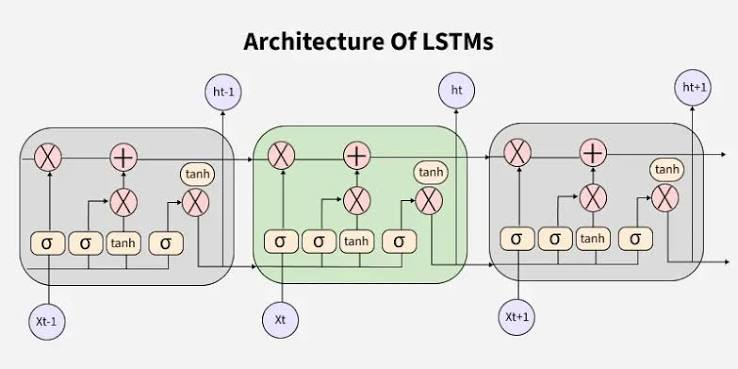

In [20]:
class LSTMClassifier(nn.Module):
    def __init__(self, vocab, dim, hidden, n_classes):
        super().__init__()
        self.emb = nn.Embedding(vocab, dim, padding_idx=0)
        self.rnn = nn.LSTM(dim, hidden, batch_first=True)
        self.fc = nn.Linear(hidden, n_classes)

    def forward(self, x, mask):
        out, (h, c) = self.rnn(self.emb(x))     # out: (B, L, H)   h: (1, B, H)
        return self.fc(h[-1])                   # the final hidden state summarizes the sentence


print("=== Model 2: LSTM ===")
h_lstm = train_seq(LSTMClassifier(len(cw2i), 32, 64, len(ANIMALS)),
                   Xtr, Mtr, ytr, Xva, Mva, yva, verbose=True)
print(f"\nbest validation accuracy: {max(h_lstm)*100:.1f}%")
print("It reads the sentence in order, so it knows which animal came first.")

=== Model 2: LSTM ===
  epoch 1/8  val acc 100.0%
  epoch 2/8  val acc 100.0%
  epoch 3/8  val acc 100.0%
  epoch 4/8  val acc 100.0%
  epoch 5/8  val acc 100.0%
  epoch 6/8  val acc 100.0%
  epoch 7/8  val acc 100.0%
  epoch 8/8  val acc 100.0%

best validation accuracy: 100.0%
It reads the sentence in order, so it knows which animal came first.


## 3.5 Attention

The LSTM works, but it has two structural weaknesses:

**It is sequential.** Step $t$ needs step $t-1$, so a 500-word document takes 500 sequential steps. That cannot be parallelized — and modern hardware is entirely about parallelism.

**It is a bottleneck.** Everything the model knows about the sentence has to squeeze through one fixed-size hidden vector, and information from early words has to survive every later step.

**Attention** removes both. Instead of passing information along a chain, let every word look **directly** at every other word and pull in what it needs.

For each word we compute three vectors from its embedding:

| | Meaning |
|---|---|
| **query** $q_i$ | what this word is looking for |
| **key** $k_j$ | what word $j$ offers |
| **value** $v_j$ | what word $j$ actually contributes |

Then word $i$'s new representation is a weighted average of all the values, where the weights come from how well its query matches each key:

$$\alpha_{ij} = \frac{\exp(q_i \cdot k_j / \sqrt{d})}{\sum_{j'} \exp(q_i \cdot k_{j'} / \sqrt{d})}, \qquad
\text{out}_i = \sum_j \alpha_{ij} v_j$$

Three observations:

* Every position is computed **independently** — one big matrix multiply, fully parallel.
* Any two words are **one step apart**, however far apart in the sentence.
* $\sqrt{d}$ keeps the dot products from growing with dimension and saturating the softmax.

One catch: attention is a weighted **sum**, so on its own it is order-blind — the same problem as mean pooling. The fix is to add a **positional encoding** to each embedding, so the vector for *"cat"* carries the fact that it was word 2.

In [21]:
class SelfAttentionClassifier(nn.Module):
    """Single-head self-attention, written out so every step is visible."""

    def __init__(self, vocab, dim, n_classes, max_len=8):
        super().__init__()
        self.emb = nn.Embedding(vocab, dim, padding_idx=0)
        self.pos = nn.Embedding(max_len, dim)              # learned positional encoding
        self.q = nn.Linear(dim, dim)
        self.k = nn.Linear(dim, dim)
        self.v = nn.Linear(dim, dim)
        self.fc = nn.Linear(dim, n_classes)
        self.dim = dim

    def forward(self, x, mask, return_attention=False):
        B, L = x.shape
        pos = torch.arange(L, device=x.device).unsqueeze(0).expand(B, L)
        h = self.emb(x) + self.pos(pos)                    # (B, L, d)  content + position

        Q, K, Vv = self.q(h), self.k(h), self.v(h)
        scores = Q @ K.transpose(1, 2) / np.sqrt(self.dim)  # (B, L, L)
        scores = scores.masked_fill(mask.unsqueeze(1) == 0, -1e9)   # ignore padding
        attn = torch.softmax(scores, dim=-1)
        out = attn @ Vv                                    # (B, L, d)

        pooled = (out * mask.unsqueeze(-1)).sum(1) / mask.sum(1, keepdim=True)
        logits = self.fc(pooled)
        return (logits, attn) if return_attention else logits


print("=== Model 3: self-attention ===")
attn_model = SelfAttentionClassifier(len(cw2i), 32, len(ANIMALS), max_len=MAXLEN)
h_attn = train_seq(attn_model, Xtr, Mtr, ytr, Xva, Mva, yva, verbose=True)
print(f"\nbest validation accuracy: {max(h_attn)*100:.1f}%")

=== Model 3: self-attention ===
  epoch 1/8  val acc 100.0%
  epoch 2/8  val acc 100.0%
  epoch 3/8  val acc 100.0%
  epoch 4/8  val acc 100.0%
  epoch 5/8  val acc 100.0%
  epoch 6/8  val acc 100.0%
  epoch 7/8  val acc 100.0%
  epoch 8/8  val acc 100.0%

best validation accuracy: 100.0%


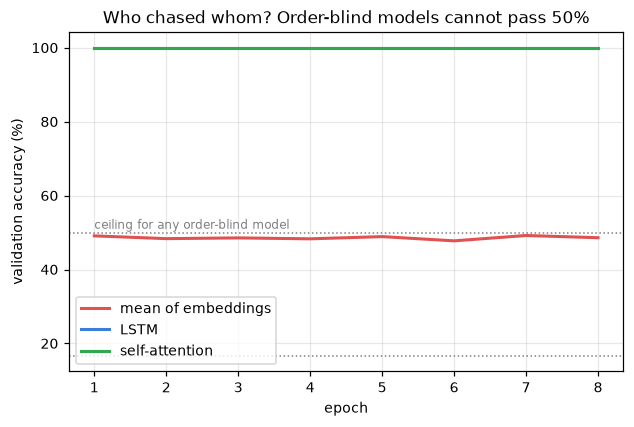

model                     best val acc
---------------------------------------
mean of embeddings               49.2%
LSTM                            100.0%
self-attention                  100.0%


In [22]:
fig, ax = plt.subplots(figsize=(6.5, 4))
for h, name, color in [(h_mean, "mean of embeddings", "#e05252"),
                       (h_lstm, "LSTM", "#3a7ddc"),
                       (h_attn, "self-attention", "#2fa84f")]:
    ax.plot(range(1, len(h) + 1), np.array(h) * 100, lw=2, color=color, label=name)
ax.axhline(50, ls=":", color="gray", lw=1)
ax.text(1, 51, "ceiling for any order-blind model", fontsize=8, color="gray")
ax.axhline(100 / len(ANIMALS), ls=":", color="gray", lw=1)
ax.set_xlabel("epoch"); ax.set_ylabel("validation accuracy (%)")
ax.set_title("Who chased whom? Order-blind models cannot pass 50%")
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.show()

print(f"{'model':<24} {'best val acc':>13}")
print("-" * 39)
for h, name in [(h_mean, "mean of embeddings"), (h_lstm, "LSTM"), (h_attn, "self-attention")]:
    print(f"{name:<24} {max(h)*100:>12.1f}%")

### Looking at what the model attends to

Attention has a pleasant side effect: the weights $\alpha_{ij}$ are interpretable. We can ask, for each word, which other words it looked at.

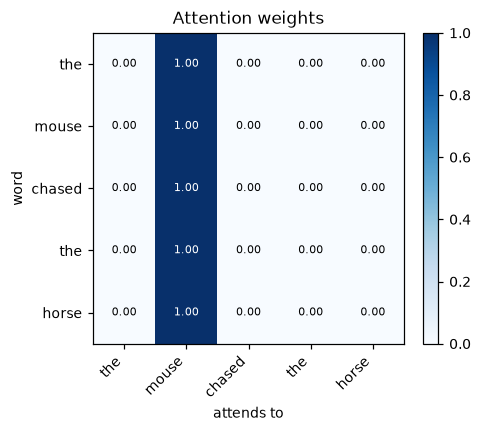

prediction: mouse  (true subject: mouse)

Each ROW shows where that word looks. Here every word attends almost entirely
to position 1 - the subject - because that is the only information the task needs.
The model discovered the grammar of this task by itself; nobody marked the subject.

In a real trained transformer attention is far more spread out, and different
heads specialize: one tracks syntax, another links pronouns to their referents.


In [23]:
attn_model.eval()
sent = "the mouse chased the horse".split()
x1, m1 = encode([sent], cw2i, MAXLEN)
with torch.no_grad():
    logits, A = attn_model(torch.from_numpy(x1).to(device),
                           torch.from_numpy(m1).to(device), return_attention=True)
A = A[0].cpu().numpy()

fig, ax = plt.subplots(figsize=(4.6, 4))
im = ax.imshow(A, cmap="Blues", vmin=0)
ax.set_xticks(range(len(sent)), sent, rotation=45, ha="right", fontsize=9)
ax.set_yticks(range(len(sent)), sent, fontsize=9)
ax.set_xlabel("attends to"); ax.set_ylabel("word")
ax.set_title("Attention weights")
for i in range(len(sent)):
    for j in range(len(sent)):
        ax.text(j, i, f"{A[i, j]:.2f}", ha="center", va="center", fontsize=7,
                color="white" if A[i, j] > 0.5 else "black")
plt.colorbar(im, fraction=0.046); plt.tight_layout(); plt.show()

print("prediction:", ANIMALS[logits.argmax(1).item()], " (true subject: mouse)")
print("\nEach ROW shows where that word looks. Here every word attends almost entirely")
print("to position 1 - the subject - because that is the only information the task needs.")
print("The model discovered the grammar of this task by itself; nobody marked the subject.")
print("\nIn a real trained transformer attention is far more spread out, and different")
print("heads specialize: one tracks syntax, another links pronouns to their referents.")

## 3.6 From attention to Transformers, and to LLMs

The 2017 paper *Attention Is All You Need* showed that if you stack attention properly, you do not need recurrence at all. A **Transformer block** is:

```
x → multi-head self-attention → add & normalize
  → feed-forward network        → add & normalize
```

with a handful of additions on top of what we just built:

| Component | Why |
|---|---|
| **Multi-head attention** | run several attentions in parallel with different projections, so one head can track syntax, another coreference, another topic |
| **Residual connections** | the same "+x" as ResNet in Session 2 — lets you stack 100 blocks |
| **Layer normalization** | stabilizes training, like BatchNorm did for CNNs |
| **Feed-forward layer** | a small MLP applied at each position, where most of the parameters live |
| **Positional encoding** | attention alone is order-blind, as we saw |

Then the whole field arrived by stacking these blocks and choosing a self-supervised task:

* **BERT** (2018) — mask out 15% of the words and predict them, reading in both directions. Gives **contextual embeddings**: *"bank"* finally gets a different vector in each sentence, which is exactly the Word2Vec limitation from Part 2.5. Best for classification, retrieval, tagging.
* **GPT** (2018 →) — predict the *next* token, left to right. Scale that up and you get ChatGPT and Claude.

> Notice that the training signal is the same one Word2Vec used in 2013: **predict a word from its context, with no human labels.** What changed is that the context is now the whole document rather than a five-word window, and the model computing it has billions of parameters instead of a lookup table.

### Which architecture should you actually use?

| Task | Sensible choice |
|---|---|
| topic / sentiment on a small dataset | mean embeddings, or TF-IDF + logistic regression. Really. |
| classification with a few thousand labels | fine-tune a small pretrained transformer (DistilBERT) |
| search, similarity, clustering | sentence-embedding models |
| generation, summarizing, chat | a pretrained large language model |
| short sequences, tiny compute budget | LSTM/GRU is still perfectly reasonable |

The Session 2 lesson applies unchanged: **almost nobody trains from scratch.** You take a model pretrained on a huge corpus and fine-tune it on your data — transfer learning is even more dominant in NLP than in vision.

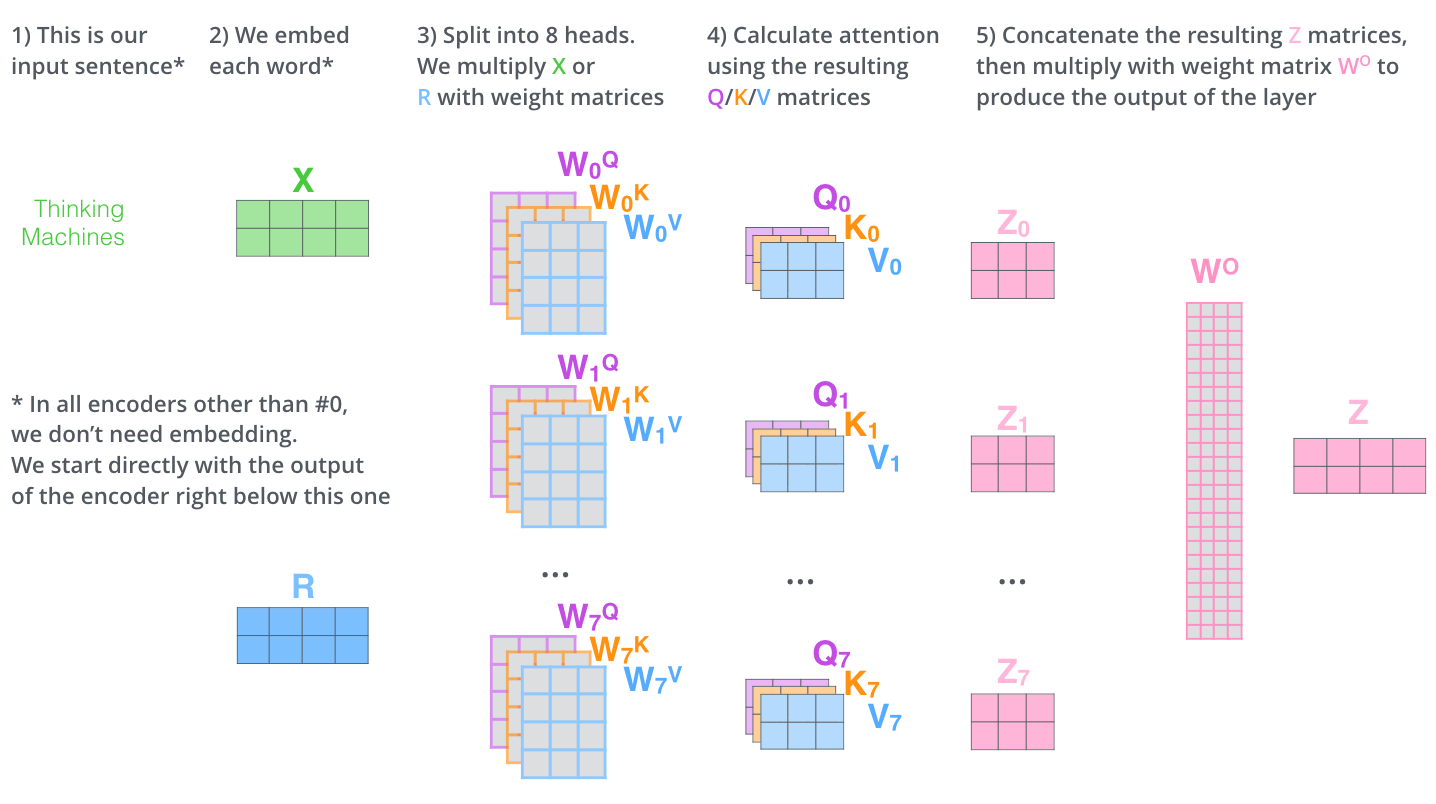

---

# Part 4 — Summary

### Today's story

| Step | Idea |
|---|---|
| Tokenization | text → tokens → integer ids (modern systems use subwords) |
| Integer ids | wrong on their own: they invent an order and a distance |
| One-hot | fixes that, but is huge, sparse, and makes every pair of words equally unrelated |
| Bag of words | a usable document representation, but throws away order |
| **Embedding** | a short dense vector per word, **learned** like any other parameter |
| **Distributional hypothesis** | meaning can be learned from context alone, with no labels |
| **Word2Vec** | train on (centre, context) pairs with negative sampling; keep the embedding matrix |
| Static-embedding limit | one vector per word, so *bank* has a single confused meaning |
| Mean pooling | strong baseline, but order-blind by construction |
| **RNN / LSTM** | read in order, share weights across time; gates give gradients a highway |
| **Attention** | every word looks directly at every other word; parallel, and no distance limit |
| **Transformer** | attention + residuals + normalization, stacked — and then BERT and GPT |

### The three sessions in one line each

1. Stop hand-designing **features** — let the network learn them.
2. Build what you know about the data into the **architecture** (images are local and shift-invariant → convolution).
3. Build what you know about **language** into the representation and the architecture (words get meaning from context → embeddings; order matters → sequence models).

The same idea each time: **find the right inductive bias, then let gradient descent do the rest.**

### Vocabulary you should now be able to explain

`token` · `vocabulary` · `one-hot` · `bag of words` · `embedding` · `distributional hypothesis` · `skip-gram` · `CBOW` · `negative sampling` · `cosine similarity` · `padding` / `masking` · `hidden state` · `RNN` · `LSTM` / `GRU` · `query, key, value` · `self-attention` · `positional encoding` · `transformer` · `contextual embedding` · `pretraining` / `fine-tuning`

---

## Exercises

**1. Window size.** Retrain Word2Vec with `window=1` and `window=5`. Small windows tend to capture syntax (words that are *interchangeable*), large windows capture topic (words that are *related*). Do the nearest neighbours change in that direction?

**2. Break the clusters.** Add a template where animals and foods appear in the *same* position, e.g. `"a PERSON likes ANIMAL"` and `"a PERSON likes FOOD"`. What happens to the 2D map, and why?

**3. CBOW.** Implement the other variant: average the context embeddings and predict the centre word. Compare its nearest neighbours with skip-gram's.

**4. Shuffle test.** Take the trained LSTM and evaluate it on sentences with the words randomly shuffled. Then do the same with the mean-embedding model. Which one's accuracy drops, and does that match the theory?

**5. A harder order task.** Generate sentences with negation — `"the food was good"` vs `"the food was not good"` vs `"the food was not bad"` — and compare the three models. Where exactly does mean pooling break?

**6. Remove the positional encoding.** Delete the `self.pos(pos)` term from the attention model and retrain on the chase task. Predict the result before you run it.

**7. Use a real model.** Install `sentence-transformers`, embed 20 sentences of your own, and print the most similar pairs. This is what a modern semantic search engine does, in about five lines.

---

## Resources

### Understanding the ideas visually

| Link | Why |
|---|---|
| [The Illustrated Word2vec](https://jalammar.github.io/illustrated-word2vec/) — Jay Alammar | The clearest explanation of Part 2 anywhere. Read it right after this notebook. |
| [The Illustrated Transformer](https://jalammar.github.io/illustrated-transformer/) | The standard explanation of Part 3.6, picture by picture. |
| [Understanding LSTM Networks](https://colah.github.io/posts/2015-08-Understanding-LSTMs/) — Chris Olah | The classic post on the gates. Still the best. |
| [The Annotated Transformer](https://nlp.seas.harvard.edu/annotated-transformer/) | The whole paper, line by line, as runnable PyTorch. |
| [Embedding Projector](https://projector.tensorflow.org/) | Explore real pretrained embeddings in 3D in your browser. |

### Building it yourself

| Link | Why |
|---|---|
| [Neural Networks: Zero to Hero](https://karpathy.ai/zero-to-hero.html) — Karpathy | Builds a character-level language model and then a GPT from scratch. The natural next step after this notebook. |
| [nanoGPT](https://github.com/karpathy/nanoGPT) | A complete, readable GPT in ~300 lines. |
| [Let's build the GPT Tokenizer](https://www.youtube.com/watch?v=zduSFxRajkE) | Byte-pair encoding explained and implemented — the tokenization from Part 1.1. |
| [PyTorch NLP tutorials](https://pytorch.org/tutorials/beginner/nlp/index.html) | Official: embeddings, RNNs, sequence models. |
| [nn.Transformer docs](https://pytorch.org/docs/stable/generated/torch.nn.Transformer.html) | When you want the built-in version. |

### Using it for real

| Link | Why |
|---|---|
| [Hugging Face NLP Course](https://huggingface.co/learn/nlp-course) | Free and excellent. How to fine-tune a pretrained model on your own data — the most practically useful thing in this list. |
| [sentence-transformers](https://sbert.net/) | Sentence embeddings for search, clustering and similarity, in a few lines. |
| [spaCy](https://spacy.io/usage/spacy-101) | Fast, production-grade classical NLP: tokenizing, tagging, entities. |
| [Hugging Face Hub](https://huggingface.co/models) | Hundreds of thousands of pretrained models, many small enough to run on a laptop. |

### Courses and papers

| Link | Why |
|---|---|
| [CS224n](https://web.stanford.edu/class/cs224n/) — Stanford | The definitive NLP course. Lectures 1–2 cover exactly Part 2. |
| [Speech and Language Processing](https://web.stanford.edu/~jurafsky/slp3/) — Jurafsky & Martin | The standard textbook, free online, updated for the LLM era. |
| [Mikolov et al., 2013 — Distributed Representations of Words and Phrases](https://arxiv.org/abs/1310.4546) | The Word2Vec paper, with negative sampling. Short and readable. |
| [Vaswani et al., 2017 — Attention Is All You Need](https://arxiv.org/abs/1706.03762) | The transformer. Probably the most influential ML paper of the decade. |
| [Devlin et al., 2018 — BERT](https://arxiv.org/abs/1810.04805) | Contextual embeddings and the pretrain/fine-tune recipe. |

> Same advice as the last two sessions: do not open all of these. Read the two Illustrated posts, then do the Hugging Face course and fine-tune a model on a dataset you actually care about. One finished project teaches more than ten tutorials.

---

### That's the course

Three sessions, one idea:

> A neural network is a function with millions of knobs and a procedure for turning them. Everything interesting — convolution, embeddings, attention — is a statement about **what kind of structure the data has**, expressed as an architecture. Learn to see that structure, and the rest is engineering.